In [49]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
from typing import TypedDict, List, Annotated
import operator
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import Send
from langgraph.graph import  StateGraph, START, END

In [50]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]


class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str


In [51]:
llm = ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')

In [52]:
def orchestrator(state: State):
    system_message = "Create a blog plan with 5-7 sections on the following topic."
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_message),
        ("human", "Topic: {topic}")
    ])

    chain = prompt | llm.with_structured_output(Plan)

    result = chain.invoke({"topic", state["topic"]})

    return {"plan": result}


In [53]:
def fanout(state: State):
    return [
        Send("worker", {"topic":state["topic"], "plan": state['plan'],"task": task}) for task in state["plan"].tasks
        ]

In [54]:
def worker(state: State):
    task = state["task"]
    topic = state["topic"]
    plan = state["plan"]
    blog_title = plan.blog_title

    system_message = "Write one clean Markdown section."

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_message),
        ("human", "Blog: {blog_title}\nTopic: {topic}\nSection: {task_title}\nBrief: {brief}\nReturn only the section content in Markdown.")
    ])

    chain = prompt | llm
    result = chain.invoke({"blog_title":blog_title,"topic": topic, "task_title":task.title, "brief": task.brief}).content.strip()

    return {"sections": [result]}

In [55]:
from pathlib import Path


def reducer(state: State):
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

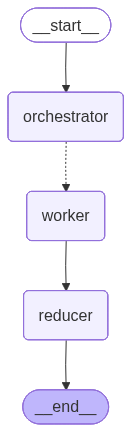

In [56]:
graph = StateGraph(State)
graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)
graph.add_edge(START, "orchestrator")

graph.add_conditional_edges("orchestrator", fanout, ["worker"])

graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)


workflow = graph.compile()

workflow

In [57]:
workflow.invoke({"topic": "Write a blog on Deep Learning", "sections": []})

ChatGoogleGenerativeAIError: Error calling model 'models/gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 33.416660305s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerMo